# Barcelona — Listings: Exploration & Cleaning
**Input :** `../../Data/raw/Barcelona/listings.csv.gz`  
**Output:** `../../Data/interim/barcelona_listings_clean.parquet`

Runs the shared `clean_listings()` pipeline, applies city-specific outlier
decisions, and exports a clean Parquet file consumed by the analysis notebook.

In [1]:
# !pip install pyarrow wordcloud textblob  # run once if needed

In [2]:
import sys
sys.path.insert(0, "../..")

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import f_oneway, ttest_ind
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from airbnb_iip.data.cleaning import (
    clean_listings, missing_report,
    standardize_property_type, rate_bucket,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 80)
pd.set_option("display.max_colwidth", 200)

## 1 · Load raw data

In [3]:
l_df_raw = pd.read_csv(
    "../../Data/raw/Barcelona/listings.csv.gz",
    compression="gzip",
    low_memory=False,
)
print(f"Shape  : {l_df_raw.shape}")
print(f"Memory : {l_df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Shape  : (19410, 79)
Memory : 87.0 MB


## 2 · Initial exploration

In [4]:
l_df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19410 entries, 0 to 19409
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            19410 non-null  int64  
 1   listing_url                                   19410 non-null  object 
 2   scrape_id                                     19410 non-null  int64  
 3   last_scraped                                  19410 non-null  object 
 4   source                                        19410 non-null  object 
 5   name                                          19410 non-null  object 
 6   description                                   18673 non-null  object 
 7   neighborhood_overview                         8986 non-null   object 
 8   picture_url                                   19410 non-null  object 
 9   host_id                                       19410 non-null 

In [5]:
display(l_df_raw.head())
display(l_df_raw.tail())

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,18674,https://www.airbnb.com/rooms/18674,20250914152803,2025-09-15,city scrape,Huge flat for 8 people close to Sagrada Familia,"110m2 apartment to rent in Barcelona. Located in the Eixample district, near the Sagrada Familia. It has a small balcony where you can see the temple of Gaudi. Capacity for 8 people. <br /><br />L...","Apartment in Barcelona located in the heart of Eixample district, within only 150 m form the great Sagrada Familia and really near of Gaudí Avenue and the famous Sant Pau Hospital . <br />All kind...",https://a0.muscache.com/pictures/13031453/413cdbfc_original.jpg,71615,https://www.airbnb.com/users/show/71615,Mireia,2010-01-19,"Barcelona, Spain","We are Mireia (47) & Maria (49), two multilingual entrepreneurs loving Barcelona and having big experience in the touristic market.\nAna and Beka from reservation department will attend you\nand f...",within an hour,96%,91%,f,https://a0.muscache.com/im/pictures/user/User/original/13242c7b-4fc1-415f-a5d7-6474d869a343.jpeg?aki_policy=profile_small,https://a0.muscache.com/im/pictures/user/User/original/13242c7b-4fc1-415f-a5d7-6474d869a343.jpeg?aki_policy=profile_x_medium,la Sagrada Família,41.0,46.0,"['email', 'phone']",t,t,"Barcelona, CT, Spain",la Sagrada Família,Eixample,41.405560,2.17262,Entire rental unit,Entire home/apt,8,2.0,2 baths,3.0,6.0,"[""Pets allowed"", ""30 inch TV"", ""Coffee maker"", ""Elevator"", ""Host greets you"", ""Pack \u2019n play/Travel crib"", ""Heating"", ""Hangers"", ""AC - split type ductless system"", ""Iron"", ""Crib"", ""Dishes and ...",$210.00,1,1125,1.0,31.0,999.0,999.0,3.0,999.0,NaN,t,12,29,56,80,2025-09-15,51,7,0,74,5,42,8820.0,2013-05-27,2025-07-31,4.34,4.40,4.56,4.64,4.62,4.82,4.32,ESFCTU000008058000039706000000000000000HUTB-002062349,t,26,26,0,0,0.34
1,23197,https://www.airbnb.com/rooms/23197,20250914152803,2025-09-14,city scrape,"Forum CCIB DeLuxe, Spacious, Large Balcony, relax","Beautiful and Spacious Apartment with Large Terrace – Just 5 Minutes from CCIB, 10 Minutes to the Beach and Marina (Port Fòrum).<br /><br />Enjoy the perfect balance of business and leisure in thi...","Strategically located in the Parc del Fòrum, a spacious area where all kinds of music festivals and events are held throughout the year.<br />The CCIB (Barcelona Internation Convention Center) is ...",https://a0.muscache.com/pictures/miso/Hosting-23197/original/0820d261-5f12-4ac9-8604-fefa1c5ec62a.jpeg,90417,https://www.airbnb.com/users/show/90417,Etain (Marnie),2010-03-09,"Catalonia, Spain","Hi there,\n\nI’m marnie, originally from Australia, but I’ve been livin

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
19405,1508763518474807782,https://www.airbnb.com/rooms/1508763518474807782,20250914152803,2025-09-15,city scrape,Sant Pau Barcelona Suites,"Meet our Sant Pau Barcelona Suites apartment!<br /><br />This apartment of 60m2, for a maximum of 2 people, is located on the ground floor of a modern building and located in the center of the cit...",NaN,https://a0.muscache.com/pictures/hosting/Hosting-1508763518474807782/original/05109293-a77d-4026-a080-93788fcb9a36.jpeg,21726991,https://www.airbnb.com/users/show/21726991,Silvia,2014-09-24,"Barcelona, Spain","I am a person \n who loves living, traveling and meeting people from all around the world . Hosting people is just amazing!\nI have several flats and boats in Barcelona and Girona Just let me kno...",within a few hours,87%,6%,f,https://a0.muscache.com/im/pictures/user/User-21726991/original/67f5ca8f-dd10-40ec-9825-95b972245c8b.jpeg?aki_policy=profile_small,https://a0.muscache.com/im/pictures/user/User-21726991/original/67f5ca8f-dd10-40ec-9825-95b972245c8b.jpeg?aki_policy=profile_x_medium,Diagonal Mar - La Mar Bella,293.0,701.0,"['email', 'phone']",t,t,NaN,el Baix Guinardó,Horta-Guinardó,41.410689,2.170413,Entire rental unit,Entire home/apt,3,1.0,1 bath,1.0,2.0,"[""Dryer"", ""Toaster"", ""Coffee maker"", ""Elevator"", ""Cooking basics"", ""Washer"", ""Heating"", ""Hangers"", ""Iron"", ""Crib"", ""Dishes and silverware"", ""Microwave"", ""Kitchen"", ""Dishwasher"", ""Stove"", ""Hot wate...",$90.00,22,365,22.0,22.0,365.0,365.0,22.0,365.0,NaN,t,30,60,90,365,2025-09-15,0,0,0,108,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HUTB-002560,f,234,233,1,0,NaN
19406,1508778122923978550,https://www.airbnb.com/rooms/1508778122923978550,20250914152803,2025-09-15,city scrape,The Ultimate Central Place,"is one of our best tourist apartments in Barcelona , ​​newly remodeled with a boutique style that combines vintage and chic trends with the traditional modernist style of Barcelona.<br />WE REQUES...",NaN,https://a0.muscache.com/pictures/hosting/Hosting-1508778122923978550/original/390b1e7a-a56f-40a1-8d9c-0c3d0bb18c48.jpeg,21726991,https://www.airbnb.com/users/show/21726991,Silvia,2014-09-24,"Barcelona, Spain","I am a person \n who loves living, traveling and meeting people from all around the world . Hosting people is just amazing!\nI have several flats and boats in Barcelona and Girona Just let me kno...",within a few hours,87%,6%,f,https://a0.muscache.com/im/pictures/user/User-21726991/original/67f5ca8f-dd10-40ec-9825-95b972245c8b.jpeg?aki_policy=profile_small,https://a0.muscache.com/im/pictures/user/User-21726991

In [6]:
l_df_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
id,19410.0,6.210978e+17,5.893311e+17,1.867400e+04,3.048967e+07,7.056056e+17,1.181663e+18,1.509435e+18
scrape_id,19410.0,2.025091e+13,0.000000e+00,2.025091e+13,2.025091e+13,2.025091e+13,2.025091e+13,2.025091e+13
host_id,19410.0,2.116496e+08,2.147334e+08,3.073000e+03,1.343129e+07,1.390639e+08,3.678971e+08,7.186126e+08
host_listings_count,19405.0,8.332765e+01,1.784109e+02,1.000000e+00,2.000000e+00,9.000000e+00,4.700000e+01,9.940000e+02
host_total_listings_count,19405.0,1.102336e+02,2.242940e+02,1.000000e+00,3.000000e+00,1.300000e+01,7.800000e+01,2.706000e+03
latitude,19410.0,4.139225e+01,1.403084e-02,4.135178e+01,4.138117e+01,4.139005e+01,4.140157e+01,4.146224e+01
longitude,19410.0,2.166968e+00,1.768924e-02,2.085593e+00,2.156510e+00,2.167765e+00,2.177668e+00,2.221830e+00
accommodates,19410.0,3.406079e+00,2.324706e+00,1.000000e+00,2.000000e+00,3.000000e+00,4.000000e+00,1.600000e+01
bathrooms,15298.0,1.429958e+00,8.227854e-01,0.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,1.400000e+01
bedrooms,17446.0,1.855784e+00,1.376608e+00,0.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,2.900000e+01


,missing_count,missing_percent
calendar_updated,19410,100.000000
host_neighbourhood,10787,55.574446
neighbourhood,10424,53.704276
neighborhood_overview,10424,53.704276
host_about,7170,36.939722
license,5480,28.232870
review_scores_checkin,4993,25.723854
review_scores_accuracy,4992,25.718702
review_scores_value,4992,25.718702
review_scores_location,4992,25.718702


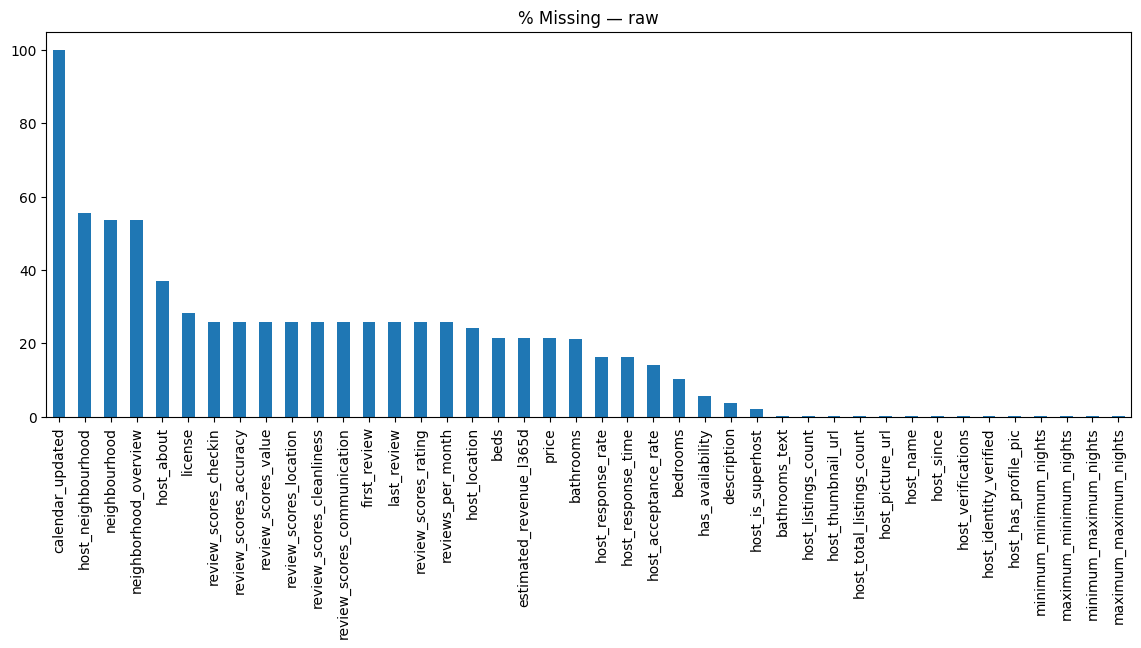

In [7]:
mr_raw = missing_report(l_df_raw)
mr_raw[mr_raw.missing_count > 0]["missing_percent"].plot(
    kind="bar", figsize=(14, 5), title="% Missing — raw"
)
display(mr_raw.head(20))

In [8]:
# Unique-value counts — categorical columns (skip long free-text)
_skip = {"description", "host_about", "neighborhood_overview", "amenities", "name"}
for col in l_df_raw.select_dtypes("object").columns.difference(_skip):
    print(f"\n{col}  ({l_df_raw[col].nunique()} unique)")
    print(l_df_raw[col].value_counts().head(6).to_string())


bathrooms_text  (38 unique)
bathrooms_text
1 bath            7579
2 baths           3879
1 shared bath     2860
1 private bath    1562
2 shared baths     788
1.5 baths          705

calendar_last_scraped  (2 unique)
calendar_last_scraped
2025-09-15    15594
2025-09-14     3816

first_review  (3805 unique)
first_review
2025-08-17    39
2025-07-06    32
2025-08-14    31
2025-07-13    31
2025-08-16    28
2025-07-31    27

has_availability  (1 unique)
has_availability
t    18346

host_acceptance_rate  (100 unique)
host_acceptance_rate
100%    4795
99%     2743
98%     1188
97%      548
70%      454
94%      448

host_has_profile_pic  (2 unique)
host_has_profile_pic
t    18781
f      624

host_identity_verified  (2 unique)
host_identity_verified
t    17697
f     1708

host_is_superhost  (2 unique)
host_is_superhost
f    15009
t     4018

host_location  (406 unique)
host_location
Barcelona, Spain            13208
Madrid, Spain                 174
Spain                          84
Bellaterra

In [9]:
# Numeric ranges — flag obvious anomalies before cleaning
for col in l_df_raw.select_dtypes(include=["int64", "float64"]).columns:
    print(f"{col}: min={l_df_raw[col].min()}, max={l_df_raw[col].max()}")

id: min=18674, max=1509434856649686912
scrape_id: min=20250914152803, max=20250914152803
host_id: min=3073, max=718612621
host_listings_count: min=1.0, max=994.0
host_total_listings_count: min=1.0, max=2706.0
latitude: min=41.35178279098418, max=41.462243
longitude: min=2.0855932, max=2.22183
accommodates: min=1, max=16
bathrooms: min=0.0, max=14.0
bedrooms: min=0.0, max=29.0
beds: min=0.0, max=127.0
minimum_nights: min=1, max=1124
maximum_nights: min=1, max=1125
minimum_minimum_nights: min=1.0, max=1124.0
maximum_minimum_nights: min=1.0, max=1124.0
minimum_maximum_nights: min=1.0, max=1125.0
maximum_maximum_nights: min=1.0, max=2147483647.0
minimum_nights_avg_ntm: min=1.0, max=1124.0
maximum_nights_avg_ntm: min=1.0, max=2135716619.5
calendar_updated: min=nan, max=nan
availability_30: min=0, max=30
availability_60: min=0, max=60
availability_90: min=0, max=90
availability_365: min=0, max=365
number_of_reviews: min=0, max=1820
number_of_reviews_ltm: min=0, max=810
number_of_reviews_l30d

In [10]:
# Duplicate check
print("Full duplicates           :", l_df_raw.duplicated().sum())
print("Duplicate listing ids     :", l_df_raw.duplicated(subset=['id']).sum())

# duplicated everything except the id 
# Count rows where everything matches except id
cols_except_id = l_df_raw.columns.difference(['id']).tolist()
dup_except_id_count = l_df_raw.duplicated(subset=cols_except_id).sum()
print("Duplicated except ids:", dup_except_id_count)    

# same name + host + coords - indicates host owns whole building. 
print("Duplicate (name+host+coords):",
      l_df_raw.duplicated(subset=['name','host_id','latitude','longitude']).sum())


Full duplicates           : 0
Duplicate listing ids     : 0
Duplicated except ids: 0
Duplicate (name+host+coords): 208


## 3 · Cleaning pipeline

`clean_listings()` handles (in order):
1. Drop `calendar_updated`, `neighbourhood` (always useless)
2. Deduplicate ignoring `id` / `listing_url`
3. Parse dates, prices, rates, booleans
4. Normalise multi-host name separators → `&`
5. Reconcile `bathrooms` / `bathrooms_text` (fixes the `fillna("mode")` bug from legacy code)
6. Hierarchical imputation — host fields → price → beds/bedrooms
7. Review-score zeros / sentinel dates for never-reviewed listings
8. Temporal features: `host_tenure_years`, `days_since_*`, `review_span_years`
9. Engineered features: `property_type_std`, rate categories, `price_cat` (city-adaptive quartiles), `description_length`
10. Drop URL / thumbnail columns

In [11]:
l_df = clean_listings(l_df_raw)
print(f"After clean_listings(): {l_df.shape}")
l_df.info()

After clean_listings(): (15199, 79)
<class 'pandas.core.frame.DataFrame'>
Index: 15199 entries, 0 to 19409
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   id                                            15199 non-null  int64         
 1   scrape_id                                     15199 non-null  int64         
 2   last_scraped                                  15199 non-null  datetime64[ns]
 3   source                                        15199 non-null  object        
 4   name                                          15199 non-null  object        
 5   description                                   14676 non-null  object        
 6   neighborhood_overview                         15199 non-null  object        
 7   picture_url                                   15199 non-null  object        
 8   host_id                            

### City-specific decisions

Document outlier thresholds and the EDA evidence that justifies them.

In [12]:
# Barcelona-specific: extreme bed / bedroom counts found during EDA above
l_df = l_df[~((l_df['beds'] == 40) | (l_df['bedrooms'] == 25))]
print(f'After city-specific outlier removal: {l_df.shape}')

After city-specific outlier removal: (15199, 79)


,missing_count,missing_percent
review_scores_cleanliness,3441,22.639647
review_scores_accuracy,3441,22.639647
review_scores_checkin,3441,22.639647
review_scores_communication,3440,22.633068
review_scores_location,3440,22.633068
review_scores_value,3440,22.633068
review_span_years,3440,22.633068
days_since_last_review,3440,22.633068
review_scores_rating,3440,22.633068
days_since_first_review,3440,22.633068


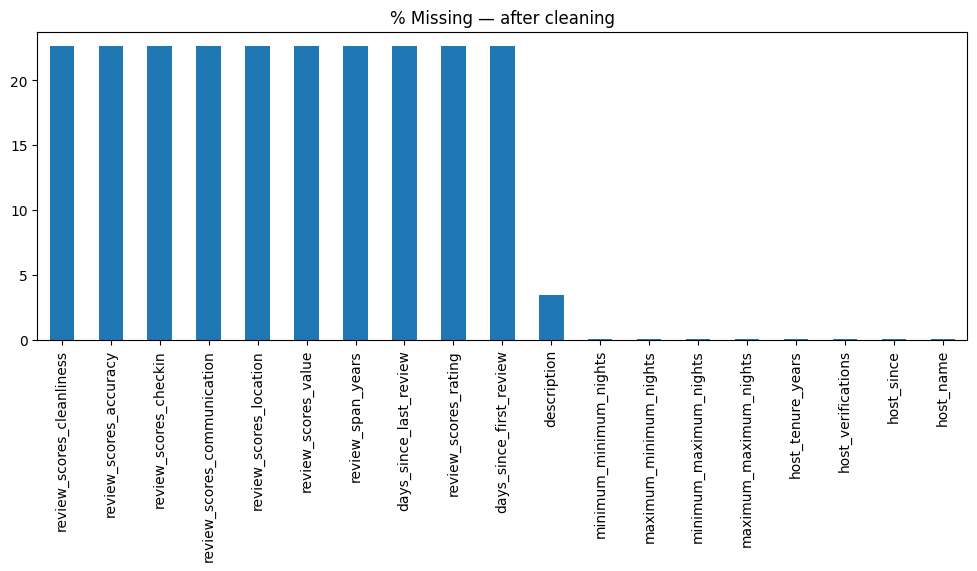

In [13]:
mr_clean = missing_report(l_df)
remaining = mr_clean[mr_clean.missing_count > 0]
if remaining.empty:
    print("No missing values remaining ✓")
else:
    display(remaining)
    remaining["missing_percent"].plot(
        kind="bar", figsize=(12, 4), title="% Missing — after cleaning"
    )

In [14]:
# Confirm final dtypes and feature set
l_df.info()
print("\nEngineered columns added:")
new_cols = set(l_df.columns) - set(l_df_raw.columns)
print(sorted(new_cols))

<class 'pandas.core.frame.DataFrame'>
Index: 15199 entries, 0 to 19409
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   id                                            15199 non-null  int64         
 1   scrape_id                                     15199 non-null  int64         
 2   last_scraped                                  15199 non-null  datetime64[ns]
 3   source                                        15199 non-null  object        
 4   name                                          15199 non-null  object        
 5   description                                   14676 non-null  object        
 6   neighborhood_overview                         15199 non-null  object        
 7   picture_url                                   15199 non-null  object        
 8   host_id                                       15199 non-null  int64    

## 4 · Export cleaned parquet

Output: `../../Data/interim/barcelona_listings_clean.parquet`

In [15]:
import pathlib

out_path = pathlib.Path("../../Data/interim/barcelona_listings_clean.parquet")
out_path.parent.mkdir(parents=True, exist_ok=True)

l_df.to_parquet(out_path, index=False, engine="pyarrow")

print(f"Saved {l_df.shape[0]:,} rows × {l_df.shape[1]} cols → {out_path}")
print(f"File size: {out_path.stat().st_size / 1e6:.1f} MB")

Saved 15,199 rows × 79 cols → ../../Data/interim/barcelona_listings_clean.parquet
File size: 8.0 MB
